In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import binned_statistic

In [2]:
plt.rcParams['figure.dpi']       = 150
plt.rcParams['axes.facecolor']   = '#0d0d0d'
plt.rcParams['figure.facecolor'] = '#0d0d0d'
plt.rcParams['axes.edgecolor']   = '#444444'
plt.rcParams['axes.labelcolor']  = 'white'
plt.rcParams['xtick.color']      = 'white'
plt.rcParams['ytick.color']      = 'white'
plt.rcParams['text.color']       = 'white'
plt.rcParams['grid.color']       = '#222222'
plt.rcParams['grid.linestyle']   = '--'
plt.rcParams['grid.alpha']       = 0.4

In [ ]:
TAX_COLORS = {
    'S'    : '#ff4444',
    'C'    : '#4444ff',
    'X'    : '#ffaa00',
    'Other': '#44ff44',
}

RESONANCES = {
    '4:1': 2.065,
    '3:1': 2.501,
    '5:2': 2.825,
    '7:3': 2.958,
    '2:1': 3.279,
}

In [4]:
core_path    = os.getcwd()
results_path = os.path.join(core_path, 'data/results')
plots_path   = os.path.join(core_path, 'plots')
os.makedirs(results_path, exist_ok=True)
os.makedirs(plots_path,   exist_ok=True)
unified_df = pd.read_pickle(os.path.join(results_path, 'unified_df.pkl'))
orbital_df = pd.read_pickle(os.path.join(core_path, 'data/lvl2/orbital_df.pkl'))

groups = ['S', 'C', 'X', 'Other']

print(f"Unified dataset : {len(unified_df):,}")
print(f"Full belt       : {len(orbital_df):,}")
print(f"\nClass counts:")
print(unified_df['Main Group'].value_counts())

Unified dataset : 1,181
Full belt       : 1,038,241

Class counts:
Main Group
S        488
C        357
X        196
Other    140
Name: count, dtype: int64


In [5]:
unified_df.head()

,Name,Bus Class,Main Group,Asteroid_id,H,a_p,e_p,sin_i_p,n,g,...,slope_vis,slope_nir,depth_07um,depth_09um,curvature,ref_044,ref_070,ref_085,ref_092,ratio_nir_vis
0,1 Ceres,C,C,1,3.41,2.767096,0.116198,0.167585,78.193318,54.070272,...,0.283761,-0.011621,0.001280,0.002835,-0.691450,0.9281,1.0146,1.0140,1.0200,1.099020
1,3 Juno,Sk,S,3,5.36,2.669366,0.233506,0.229226,82.528181,43.635655,...,0.893242,-0.578419,0.001005,0.044849,-2.899067,0.8692,1.1041,1.0333,1.0038,1.154855
2,4 Vesta,V,Other,4,3.31,2.361513,0.098758,0.111336,99.188833,36.872897,...,0.646526,-1.703458,0.010461,0.160461,-4.521508,0.8929,1.0741,0.8727,0.7943,0.889573
3,6 Hebe,S,S,6,5.76,2.425271,0.158486,0.247863,95.303184,31.568209,...,1.180940,-0.520020,0.006466,0.035817,-3.336018,0.8499,1.1442,1.0793,1.0705,1.259560
4,7 Iris,S,S,7,5.51,2.386211,0.212552,0.111339,97.653672,38.403324,...,1.208602,-0.630751,0.014464,0.053318,-3.595413,0.8347,1.1524,1.0882,1.0550,1.263927


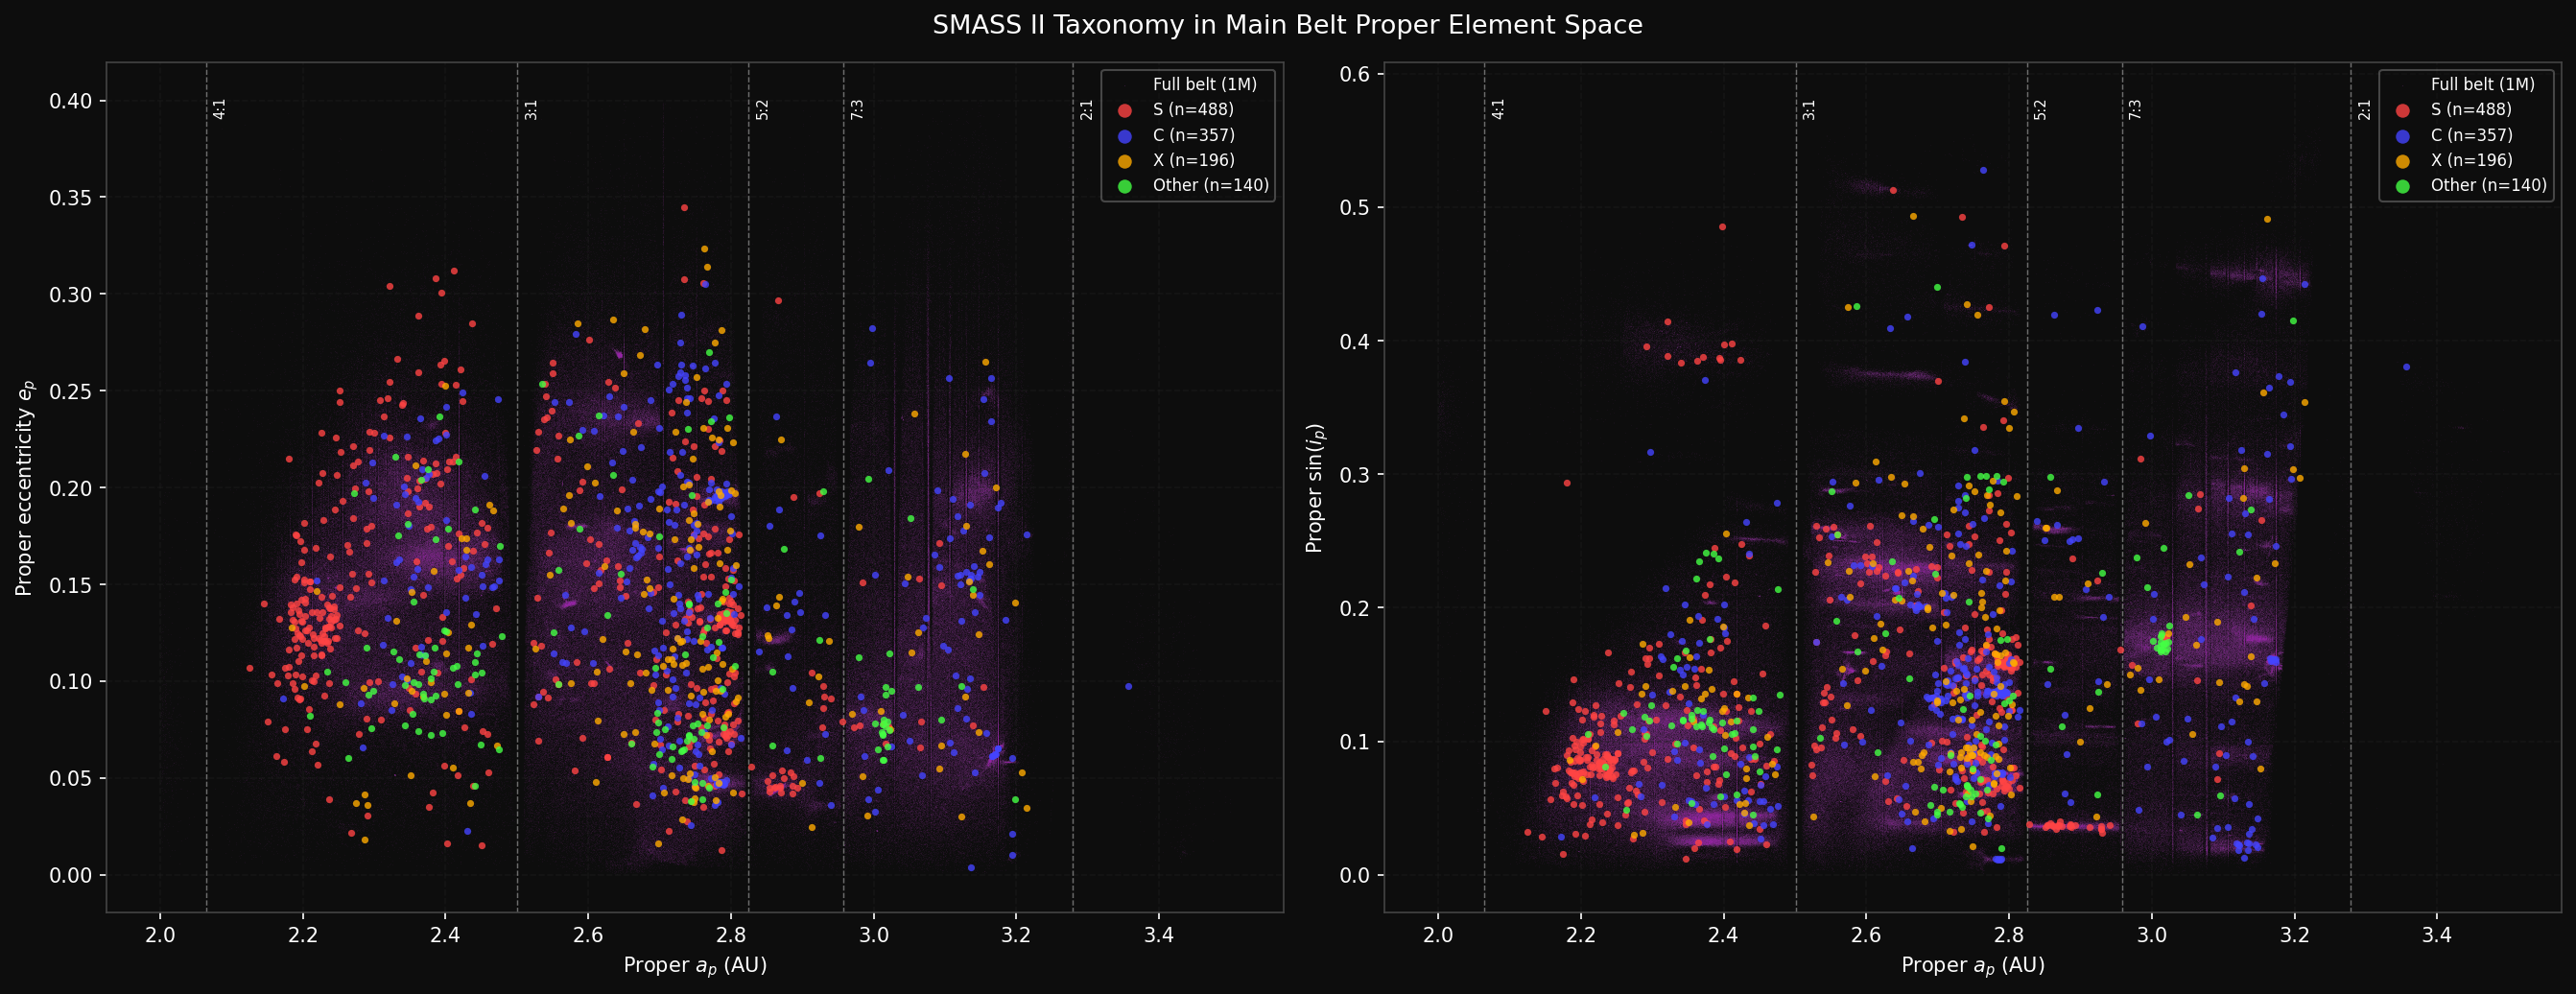

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, (ycol, ylabel) in zip(axes, [
    ('e_p',     'Proper eccentricity $e_p$'),
    ('sin_i_p', 'Proper $\\sin(i_p)$'),
]):
    # Full belt background
    ax.scatter(
        orbital_df['a_p'], orbital_df[ycol],
        s=0.02, c="#B648C7", alpha=0.4,
        linewidths=0, label='Full belt (1M)'
    )

    # SMASS II asteroids colored by taxonomy
    for group in groups:
        mask = unified_df['Main Group'] == group
        ax.scatter(
            unified_df.loc[mask, 'a_p'],
            unified_df.loc[mask, ycol],
            s=12, c=TAX_COLORS[group], alpha=0.8,
            linewidths=0, label=f'{group} (n={mask.sum()})',
            zorder=3
        )

    # Resonances
    for name, loc in RESONANCES.items():
        ax.axvline(loc, color='white', linewidth=0.7,
                   linestyle='--', alpha=0.4)
        ax.text(loc + 0.01, 0.96, name,
                transform=ax.get_xaxis_transform(),
                color='white', fontsize=7, rotation=90, va='top')

    ax.set_xlabel('Proper $a_p$ (AU)')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8, markerscale=2,
              loc='upper right', framealpha=0.3)
    ax.grid(True)

plt.suptitle('SMASS II Taxonomy in Main Belt Proper Element Space', fontsize=13)
plt.tight_layout()
# plt.savefig(os.path.join(plots_path, '02_belt_taxonomy_overlay.png'), dpi=200, bbox_inches='tight')
plt.show()

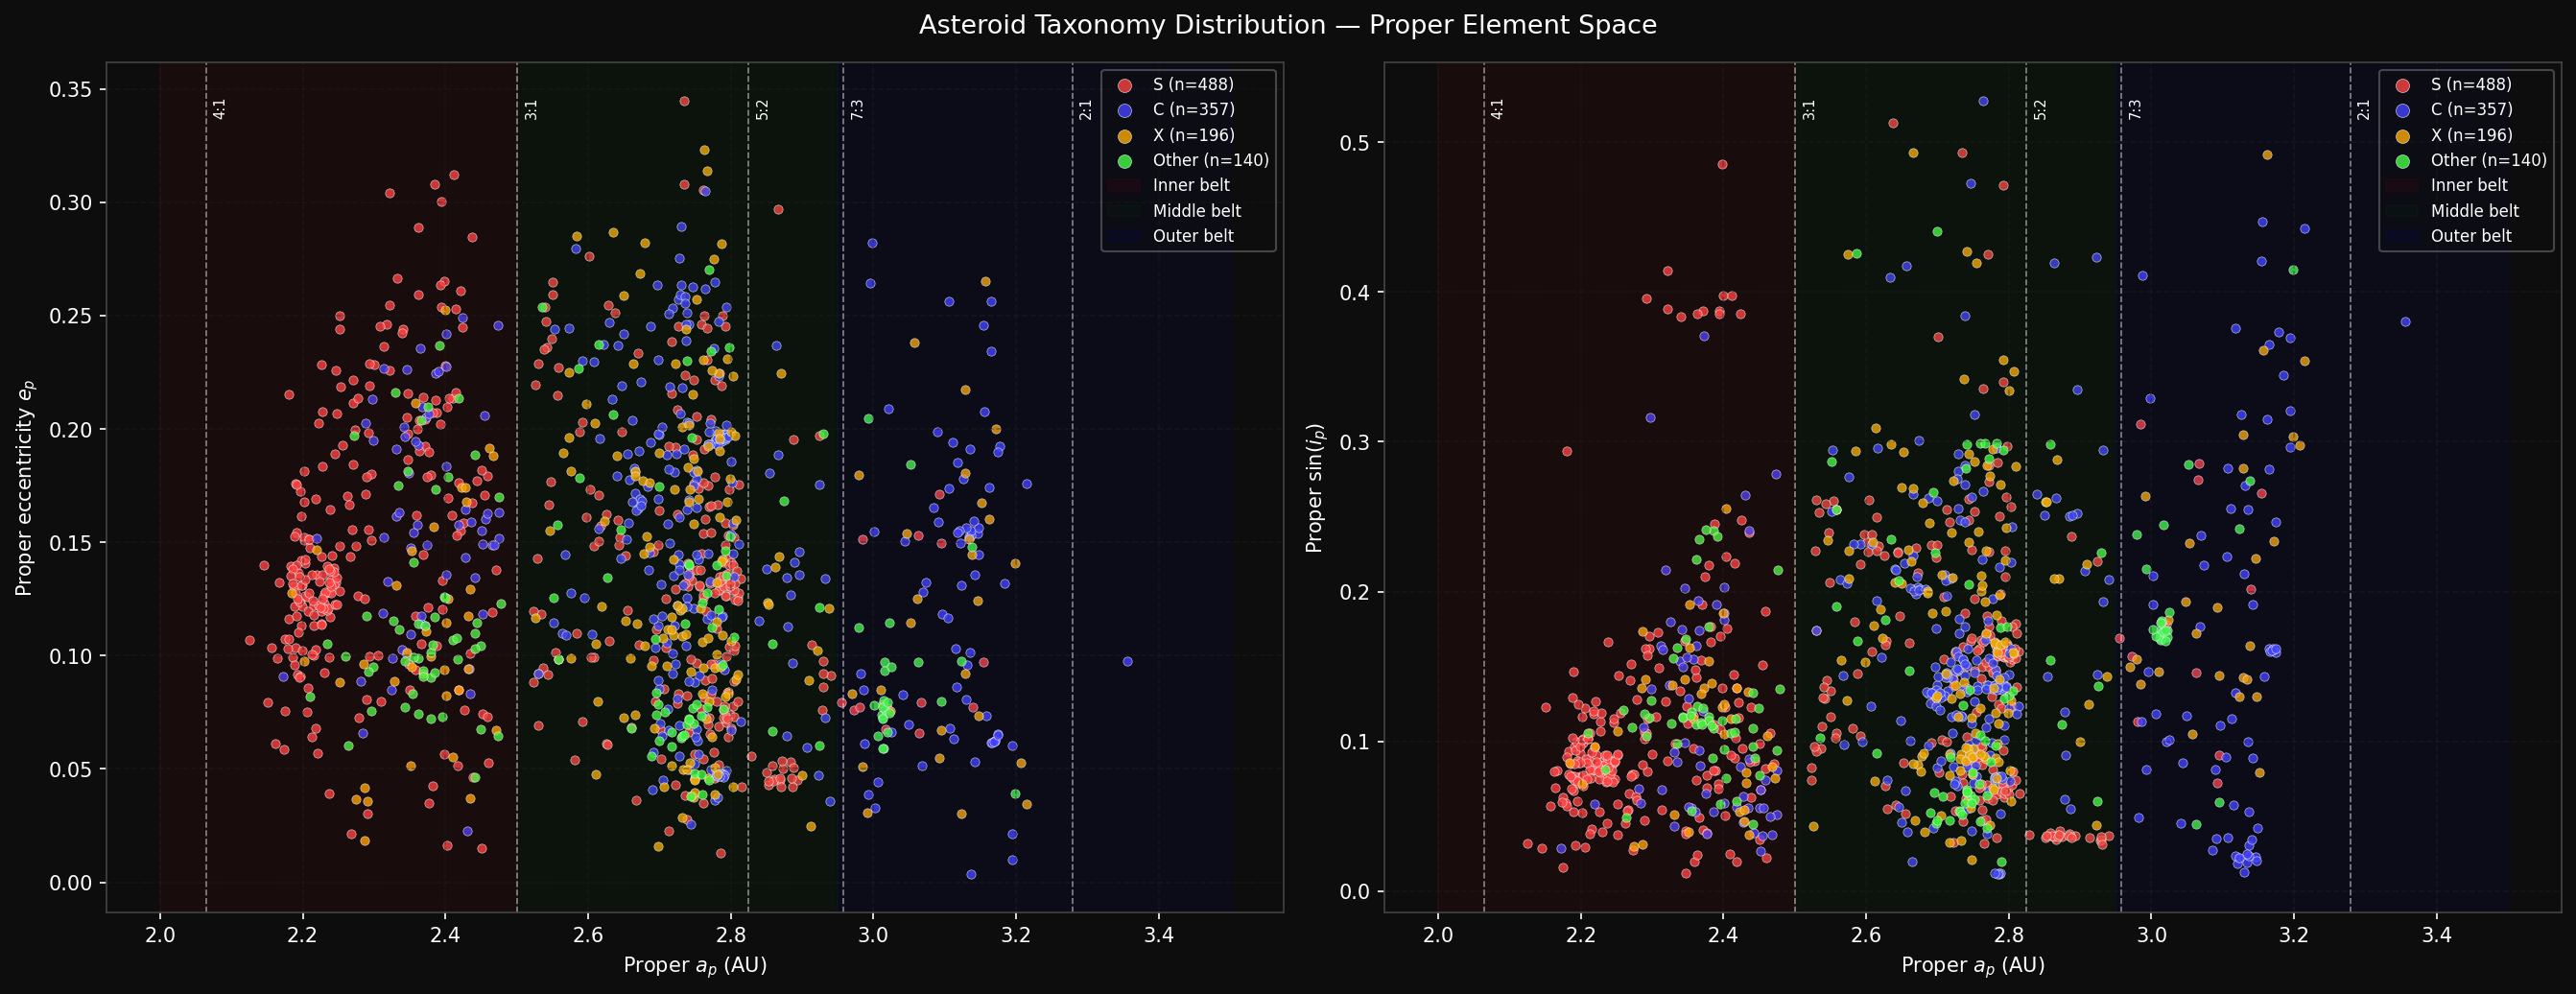

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, (ycol, ylabel) in zip(axes, [
    ('e_p',     'Proper eccentricity $e_p$'),
    ('sin_i_p', 'Proper $\\sin(i_p)$'),
]):
    for group in groups:
        mask = unified_df['Main Group'] == group
        ax.scatter(
            unified_df.loc[mask, 'a_p'],
            unified_df.loc[mask, ycol],
            s=20, c=TAX_COLORS[group], alpha=0.8,
            linewidths=0.3, edgecolors='white',
            label=f'{group} (n={mask.sum()})',
        )

    # Belt zone shading
    ax.axvspan(2.0,  2.5,  alpha=0.05, color='red',   label='Inner belt')
    ax.axvspan(2.5,  2.95, alpha=0.05, color='green',  label='Middle belt')
    ax.axvspan(2.95, 3.5,  alpha=0.05, color='blue',   label='Outer belt')

    for name, loc in RESONANCES.items():
        ax.axvline(loc, color='white', linewidth=0.8,
                   linestyle='--', alpha=0.5)
        ax.text(loc + 0.01, 0.96, name,
                transform=ax.get_xaxis_transform(),
                color='white', fontsize=7, rotation=90, va='top')

    ax.set_xlabel('Proper $a_p$ (AU)')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8, markerscale=1.5,
              loc='upper right', framealpha=0.3)
    ax.grid(True)

plt.suptitle('Asteroid Taxonomy Distribution — Proper Element Space', fontsize=13)
plt.tight_layout()
# plt.savefig(os.path.join(plots_path, '02_taxonomy_proper_elements.png'),
#             dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
import ipywidgets as widgets
import matplotlib.pyplot as plt

# Widgets
tax_class_widget = widgets.Dropdown(
    options=['Main Group', 'Bus Class'],
    value='Main Group',
    description='Taxonomy:'
)

sub_class_widget = widgets.Dropdown(
    description='Class:'
)

yaxis_widget = widgets.Dropdown(
    options={
        'Proper eccentricity': 'e_p',
        'Proper sin(i)': 'sin_i_p'
    },
    value='e_p',
    description='Y-axis:'
)

# Update available classes
def update_sub_class(*args):
    sub_class_widget.options = sorted(
        unified_df[tax_class_widget.value]
        .dropna()
        .unique()
    )

tax_class_widget.observe(update_sub_class, names='value')
update_sub_class()

# Plot function
def plot_class_distribution(tax_class,
                            sub_class,
                            ycol):

    mask = unified_df[tax_class] == sub_class

    n = mask.sum()

    plt.figure(figsize=(12,7))

    plt.scatter(
        unified_df.loc[mask, 'a_p'],
        unified_df.loc[mask, ycol],
        s=25,
        color=TAX_COLORS.get(sub_class, 'white'),
        edgecolors='white',
        linewidths=0.3,
        alpha=0.8
    )

    # Belt zones
    plt.axvspan(2.0, 2.5, alpha=0.05, color='red')
    plt.axvspan(2.5, 2.95, alpha=0.05, color='green')
    plt.axvspan(2.95, 3.5, alpha=0.05, color='blue')

    # Resonances
    for name, loc in RESONANCES.items():

        plt.axvline(
            loc,
            color='white',
            linestyle='--',
            linewidth=0.8,
            alpha=0.5
        )

        plt.text(
            loc + 0.01,
            0.96,
            name,
            transform=plt.gca().get_xaxis_transform(),
            fontsize=7,
            rotation=90,
            va='top'
        )

    plt.xlabel(r'Proper $a_p$ (AU)')

    if ycol == 'e_p':
        plt.ylabel(r'Proper eccentricity $e_p$')
    else:
        plt.ylabel(r'Proper $\sin(i_p)$')

    plt.title(
        f'{sub_class} ({tax_class})\n'
        f'n = {n}'
    )

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# Interactive widget
widgets.interactive(
    plot_class_distribution,
    tax_class=tax_class_widget,
    sub_class=sub_class_widget,
    ycol=yaxis_widget
)

interactive(children=(Dropdown(description='Taxonomy:', options=('Main Group', 'Bus Class'), value='Main Group…

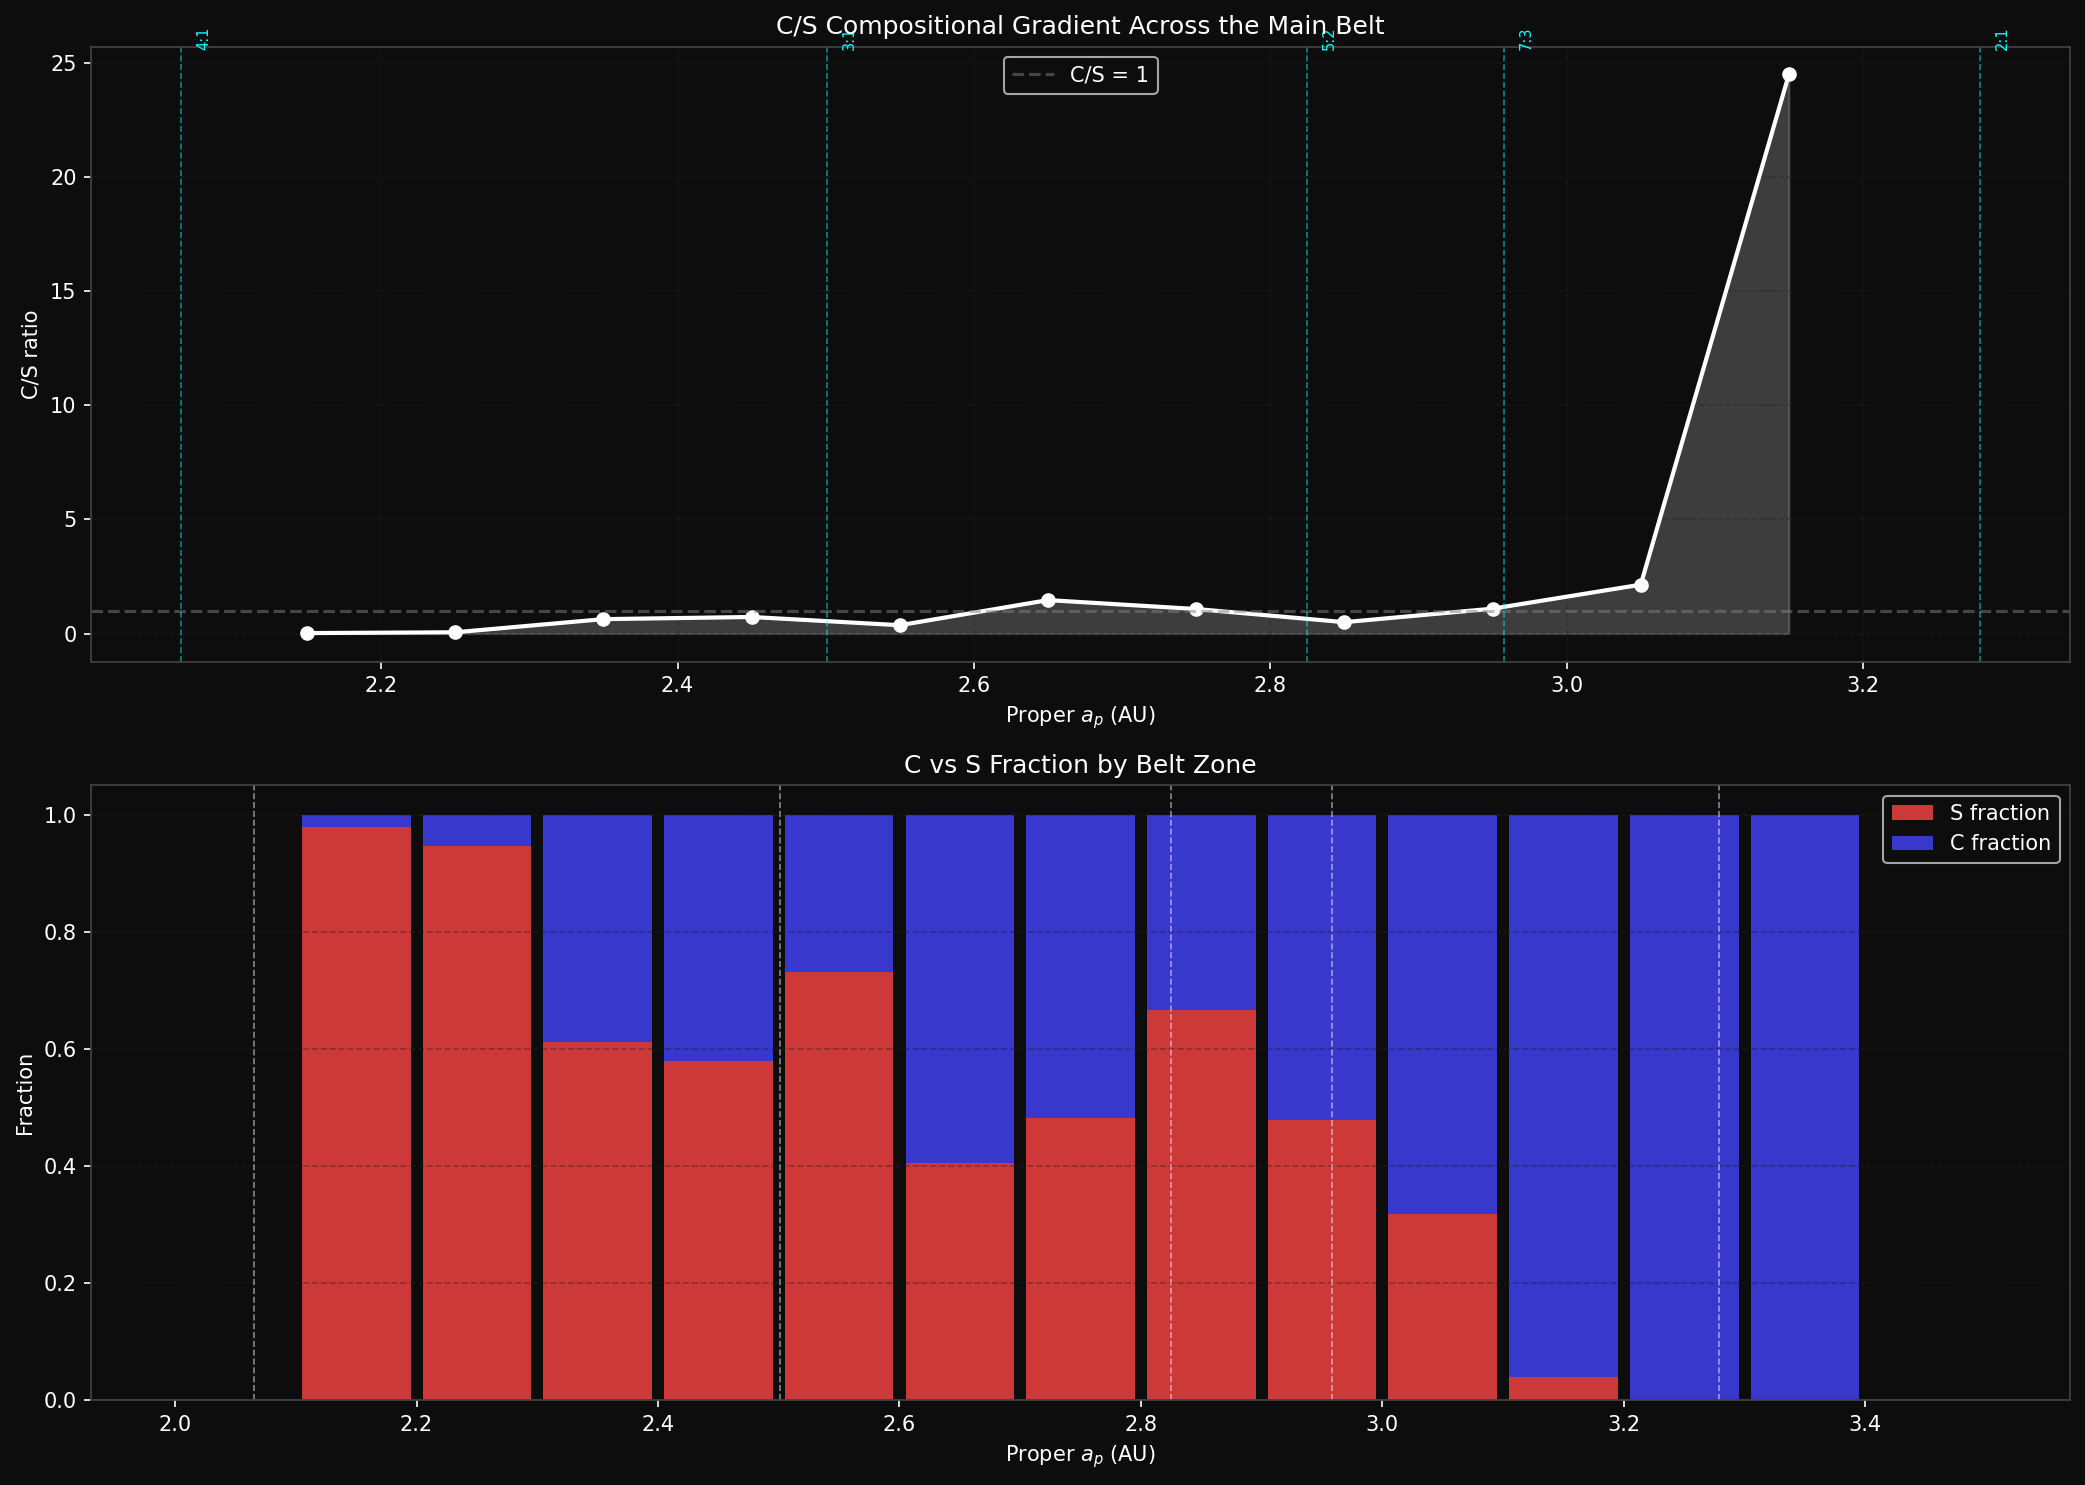


C/S gradient table:
    bin_center  n_total  n_c  n_s   cs_ratio  c_fraction  s_fraction
1         2.15       48    1   47   0.021277    0.020833    0.979167
2         2.25      112    6  106   0.056604    0.053571    0.946429
3         2.35       80   31   49   0.632653    0.387500    0.612500
4         2.45       57   24   33   0.727273    0.421053    0.578947
5         2.55       41   11   30   0.366667    0.268293    0.731707
6         2.65       74   44   30   1.466667    0.594595    0.405405
7         2.75      272  141  131   1.076336    0.518382    0.481618
8         2.85       63   21   42   0.500000    0.333333    0.666667
9         2.95       23   12   11   1.090909    0.521739    0.478261
10        3.05       22   15    7   2.142857    0.681818    0.318182
11        3.15       51   49    2  24.500000    0.960784    0.039216


In [8]:
bins     = np.arange(2.0, 3.55, 0.1)   # 0.1 AU bins
bin_centers = (bins[:-1] + bins[1:]) / 2

cs_df = unified_df[unified_df['Main Group'].isin(['C', 'S'])].copy()

cs_counts = []
for i in range(len(bins) - 1):
    bin_mask = (cs_df['a_p'] >= bins[i]) & (cs_df['a_p'] < bins[i+1])
    bin_data = cs_df[bin_mask]
    n_total  = len(bin_data)
    n_c      = (bin_data['Main Group'] == 'C').sum()
    n_s      = (bin_data['Main Group'] == 'S').sum()
    cs_ratio = n_c / n_s if n_s > 0 else np.nan
    cs_counts.append({
        'bin_center': bin_centers[i],
        'n_total': n_total,
        'n_c': n_c,
        'n_s': n_s,
        'cs_ratio': cs_ratio,
        'c_fraction': n_c / n_total if n_total > 0 else np.nan,
        's_fraction': n_s / n_total if n_total > 0 else np.nan,
    })

cs_gradient = pd.DataFrame(cs_counts)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# C/S ratio
ax = axes[0]
valid = cs_gradient['cs_ratio'].notna() & (cs_gradient['n_total'] >= 3)
ax.plot(cs_gradient.loc[valid, 'bin_center'],
        cs_gradient.loc[valid, 'cs_ratio'],
        'o-', color='#ffffff', linewidth=2, markersize=6)
ax.fill_between(cs_gradient.loc[valid, 'bin_center'],
                cs_gradient.loc[valid, 'cs_ratio'],
                alpha=0.2, color='white')
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.5, label='C/S = 1')

for name, loc in RESONANCES.items():
    ax.axvline(loc, color='cyan', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.text(loc + 0.01, ax.get_ylim()[1] if not np.isnan(ax.get_ylim()[1]) else 3,
            name, color='cyan', fontsize=7, rotation=90)

ax.set_xlabel('Proper $a_p$ (AU)')
ax.set_ylabel('C/S ratio')
ax.set_title('C/S Compositional Gradient Across the Main Belt')
ax.legend()
ax.grid(True)

# Stacked fraction plot
ax = axes[1]
ax.bar(cs_gradient['bin_center'],
       cs_gradient['s_fraction'].fillna(0),
       width=0.09, color=TAX_COLORS['S'],
       alpha=0.8, label='S fraction')
ax.bar(cs_gradient['bin_center'],
       cs_gradient['c_fraction'].fillna(0),
       width=0.09, color=TAX_COLORS['C'],
       alpha=0.8, label='C fraction',
       bottom=cs_gradient['s_fraction'].fillna(0))

for name, loc in RESONANCES.items():
    ax.axvline(loc, color='white', linewidth=0.8, linestyle='--', alpha=0.5)

ax.set_xlabel('Proper $a_p$ (AU)')
ax.set_ylabel('Fraction')
ax.set_title('C vs S Fraction by Belt Zone')
ax.legend()
ax.grid(True, axis='y')

plt.tight_layout()
# plt.savefig(os.path.join(plots_path, '02_cs_gradient.png'),
#             dpi=200, bbox_inches='tight')
plt.show()

print("\nC/S gradient table:")
print(cs_gradient[cs_gradient['n_total'] >= 3].to_string())

=== Taxonomy by Belt Zone ===

Inner (2.0–2.5) (n=387):
  S       :  235  (60.7%)
  C       :   62  (16.0%)
  X       :   37  (9.6%)
  Other   :   53  (13.7%)

Middle (2.5–2.95) (n=656):
  S       :  240  (36.6%)
  C       :  223  (34.0%)
  X       :  131  (20.0%)
  Other   :   62  (9.5%)

Outer (2.95–3.5) (n=138):
  S       :   13  (9.4%)
  C       :   72  (52.2%)
  X       :   28  (20.3%)
  Other   :   25  (18.1%)



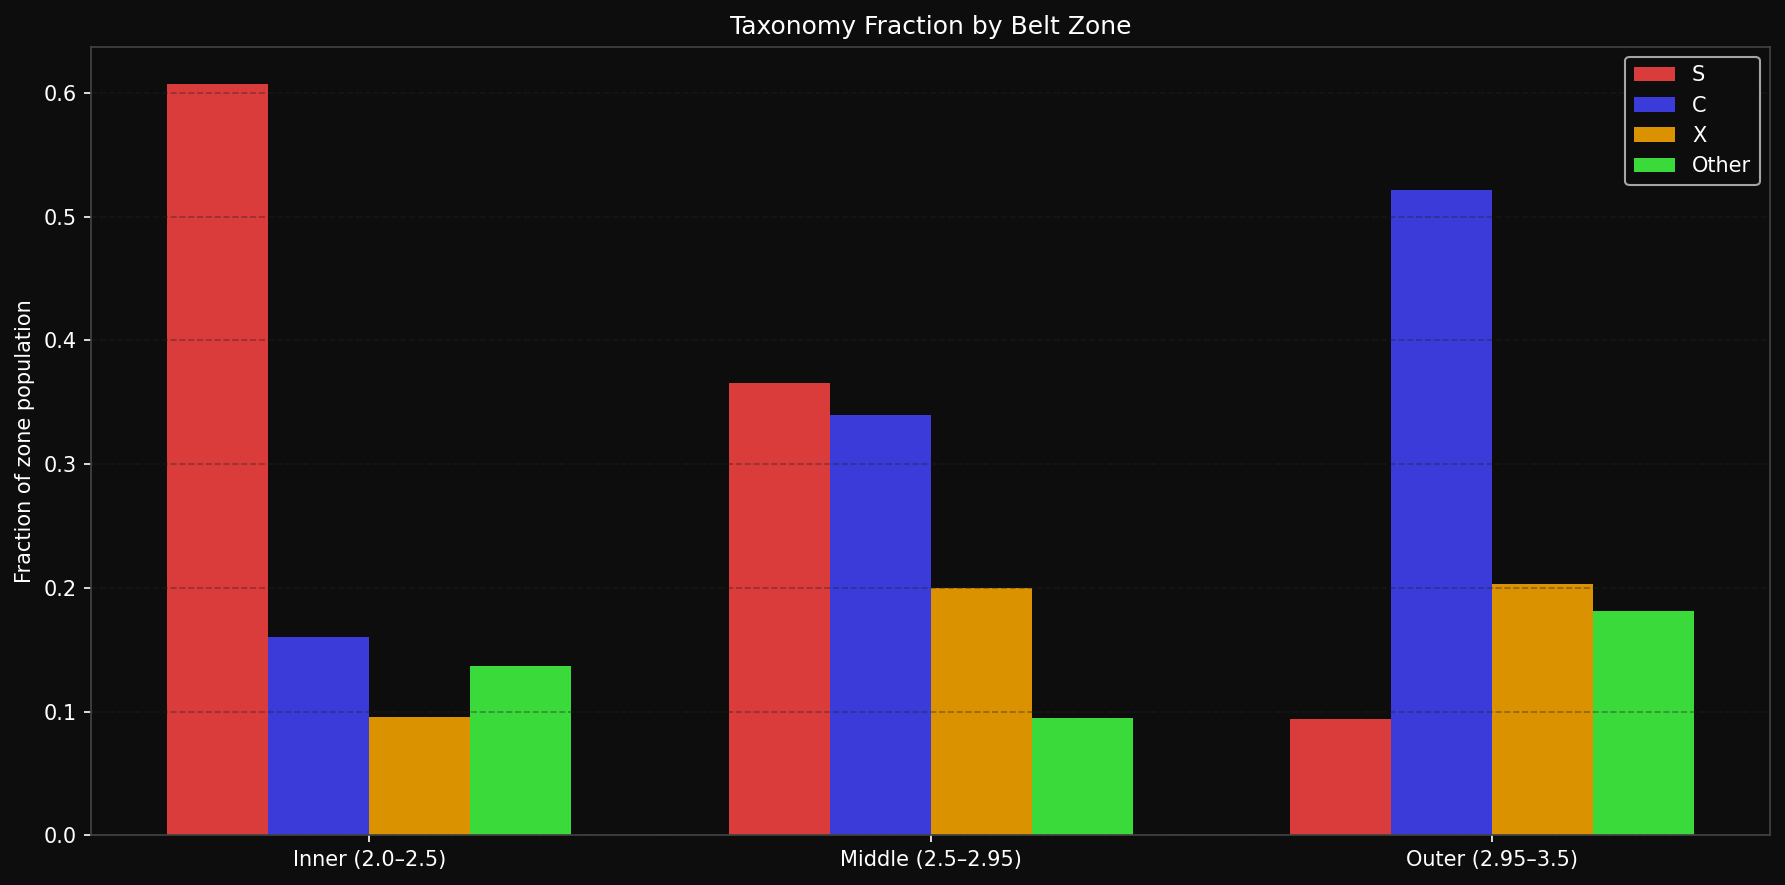

In [16]:
zone_taxonomy = []

zones = {
    'Inner\n(2.0–2.5)' : (2.0,  2.5),
    'Middle\n(2.5–2.95)': (2.5,  2.95),
    'Outer\n(2.95–3.5)' : (2.95, 3.5),
}

print("=== Taxonomy by Belt Zone ===\n")
for zone_name, (a_min, a_max) in zones.items():
    zone = unified_df[
        (unified_df['a_p'] >= a_min) &
        (unified_df['a_p'] <  a_max)
    ]
    print(f"{zone_name.replace(chr(10),' ')} (n={len(zone)}):")
    for group in groups:
        count = (zone['Main Group'] == group).sum()
        pct   = 100 * count / len(zone) if len(zone) > 0 else 0
        print(f"  {group:<8}: {count:>4}  ({pct:.1f}%)")
    print()
    for group in groups:
        count = (zone['Main Group'] == group).sum()
        zone_taxonomy.append({
            'zone': zone_name, 'group': group,
            'count': count,
            'fraction': count / len(zone) if len(zone) > 0 else 0
        })

zone_tax_df = pd.DataFrame(zone_taxonomy)

fig, ax = plt.subplots(figsize=(12, 6))
zone_names  = list(zones.keys())
x           = np.arange(len(zone_names))
width       = 0.18
offsets     = [-1.5, -0.5, 0.5, 1.5]

for group, offset in zip(groups, offsets):
    vals = [
        zone_tax_df[(zone_tax_df['zone'] == z) &
                    (zone_tax_df['group'] == group)]['fraction'].values[0]
        for z in zone_names
    ]
    ax.bar(x + offset * width, vals, width,
           color=TAX_COLORS[group], alpha=0.85,
           label=group, edgecolor='none')

ax.set_xticks(x)
ax.set_xticklabels([z.replace('\n', ' ') for z in zone_names])
ax.set_ylabel('Fraction of zone population')
ax.set_title('Taxonomy Fraction by Belt Zone')
ax.legend()
ax.grid(True, axis='y')

plt.tight_layout()
# plt.savefig(os.path.join(plots_path, '02_taxonomy_by_zone.png'),
#             dpi=200, bbox_inches='tight')
plt.show()

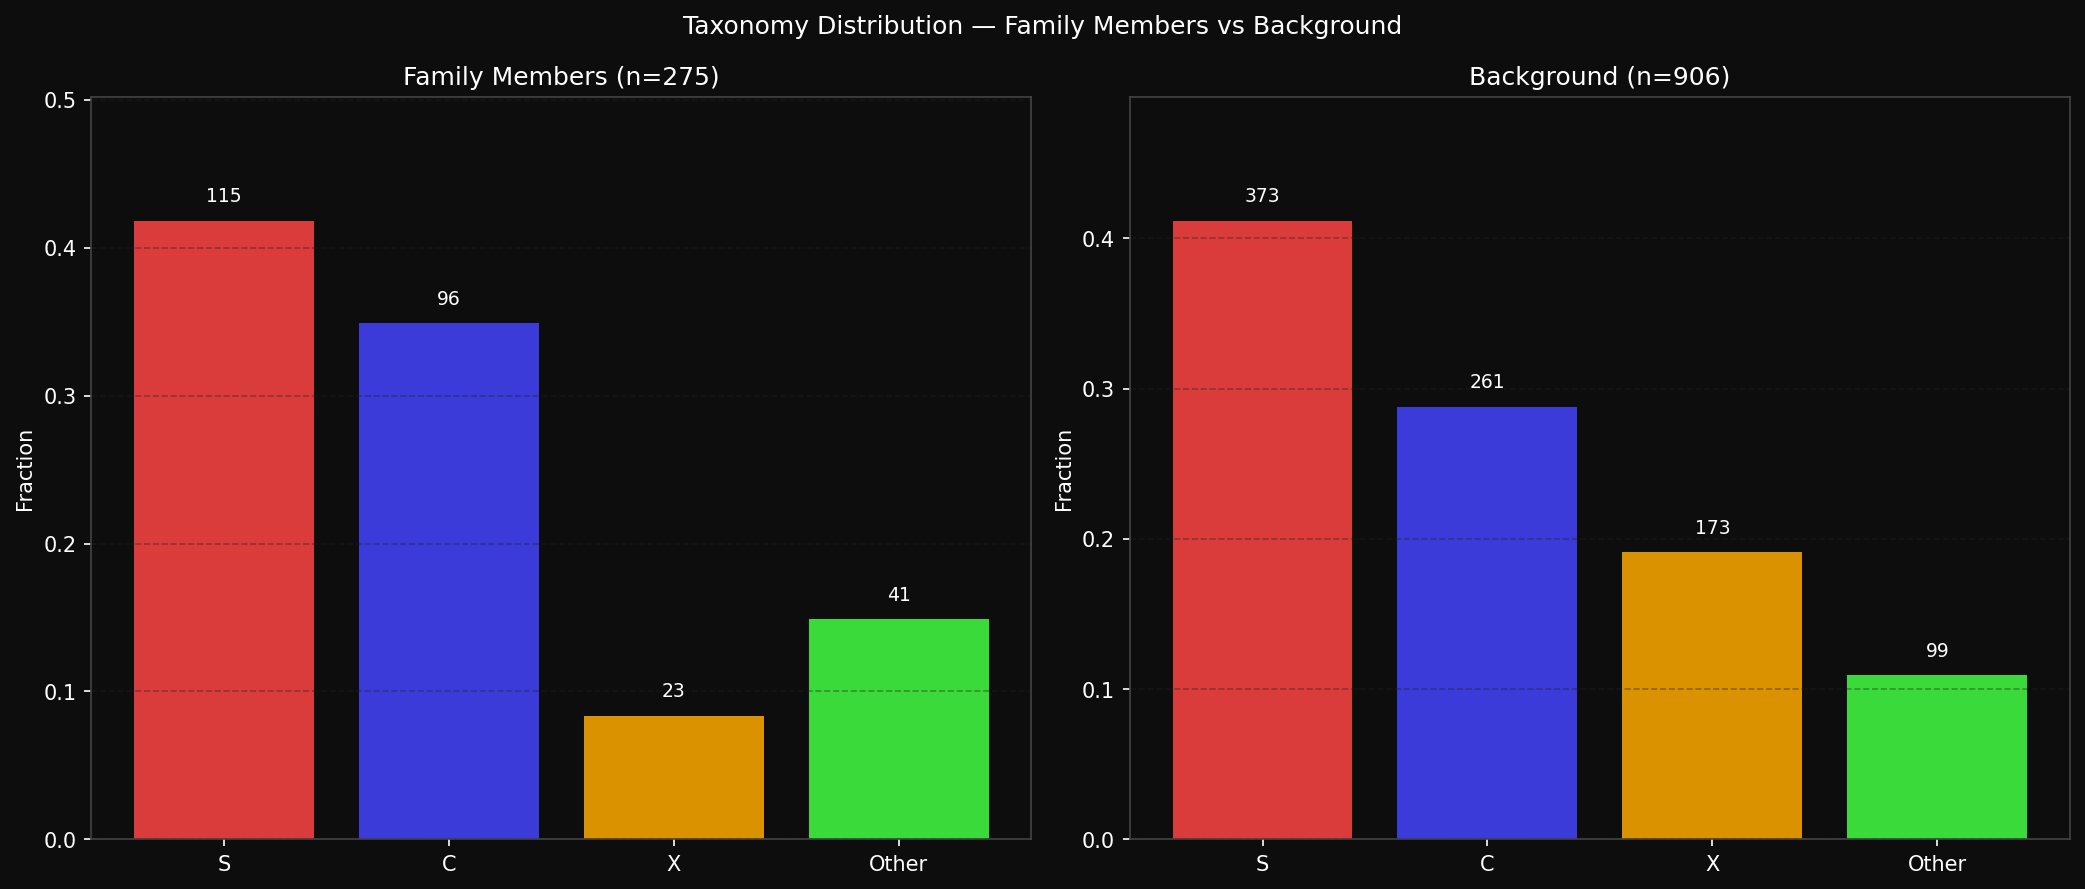

Chi-square test — family vs background taxonomy distribution:
  chi2 = 20.0800, p = 1.6339e-04, dof = 3
  Significantly different (α=0.05)


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (pop_mask, pop_name) in zip(axes, [
    (unified_df['is_family_member'],  'Family Members (n=275)'),
    (~unified_df['is_family_member'], 'Background (n=906)'),
]):
    pop = unified_df[pop_mask]
    counts   = [( pop['Main Group'] == g).sum() for g in groups]
    fractions = [c / len(pop) for c in counts]
    colors_   = [TAX_COLORS[g] for g in groups]

    bars = ax.bar(groups, fractions, color=colors_,
                  edgecolor='none', alpha=0.85)

    # Add count labels
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                str(count), ha='center', va='bottom', fontsize=9)

    ax.set_ylabel('Fraction')
    ax.set_title(pop_name)
    ax.set_ylim(0, max(fractions) * 1.2)
    ax.grid(True, axis='y')

plt.suptitle('Taxonomy Distribution — Family Members vs Background', fontsize=12)
plt.tight_layout()
# plt.savefig(os.path.join(plots_path, '02_family_vs_background_taxonomy.png'),
#             dpi=200, bbox_inches='tight')
plt.show()

# Chi-square test — are the distributions significantly different?
from scipy.stats import chi2_contingency

fam_counts = [(unified_df[unified_df['is_family_member']]['Main Group'] == g).sum()
              for g in groups]
bg_counts  = [(unified_df[~unified_df['is_family_member']]['Main Group'] == g).sum()
              for g in groups]

contingency = np.array([fam_counts, bg_counts])
chi2, p, dof, _ = chi2_contingency(contingency)
print(f"Chi-square test — family vs background taxonomy distribution:")
print(f"  chi2 = {chi2:.4f}, p = {p:.4e}, dof = {dof}")
print(f"  {'Significantly different' if p < 0.05 else 'Not significantly different'} (α=0.05)")

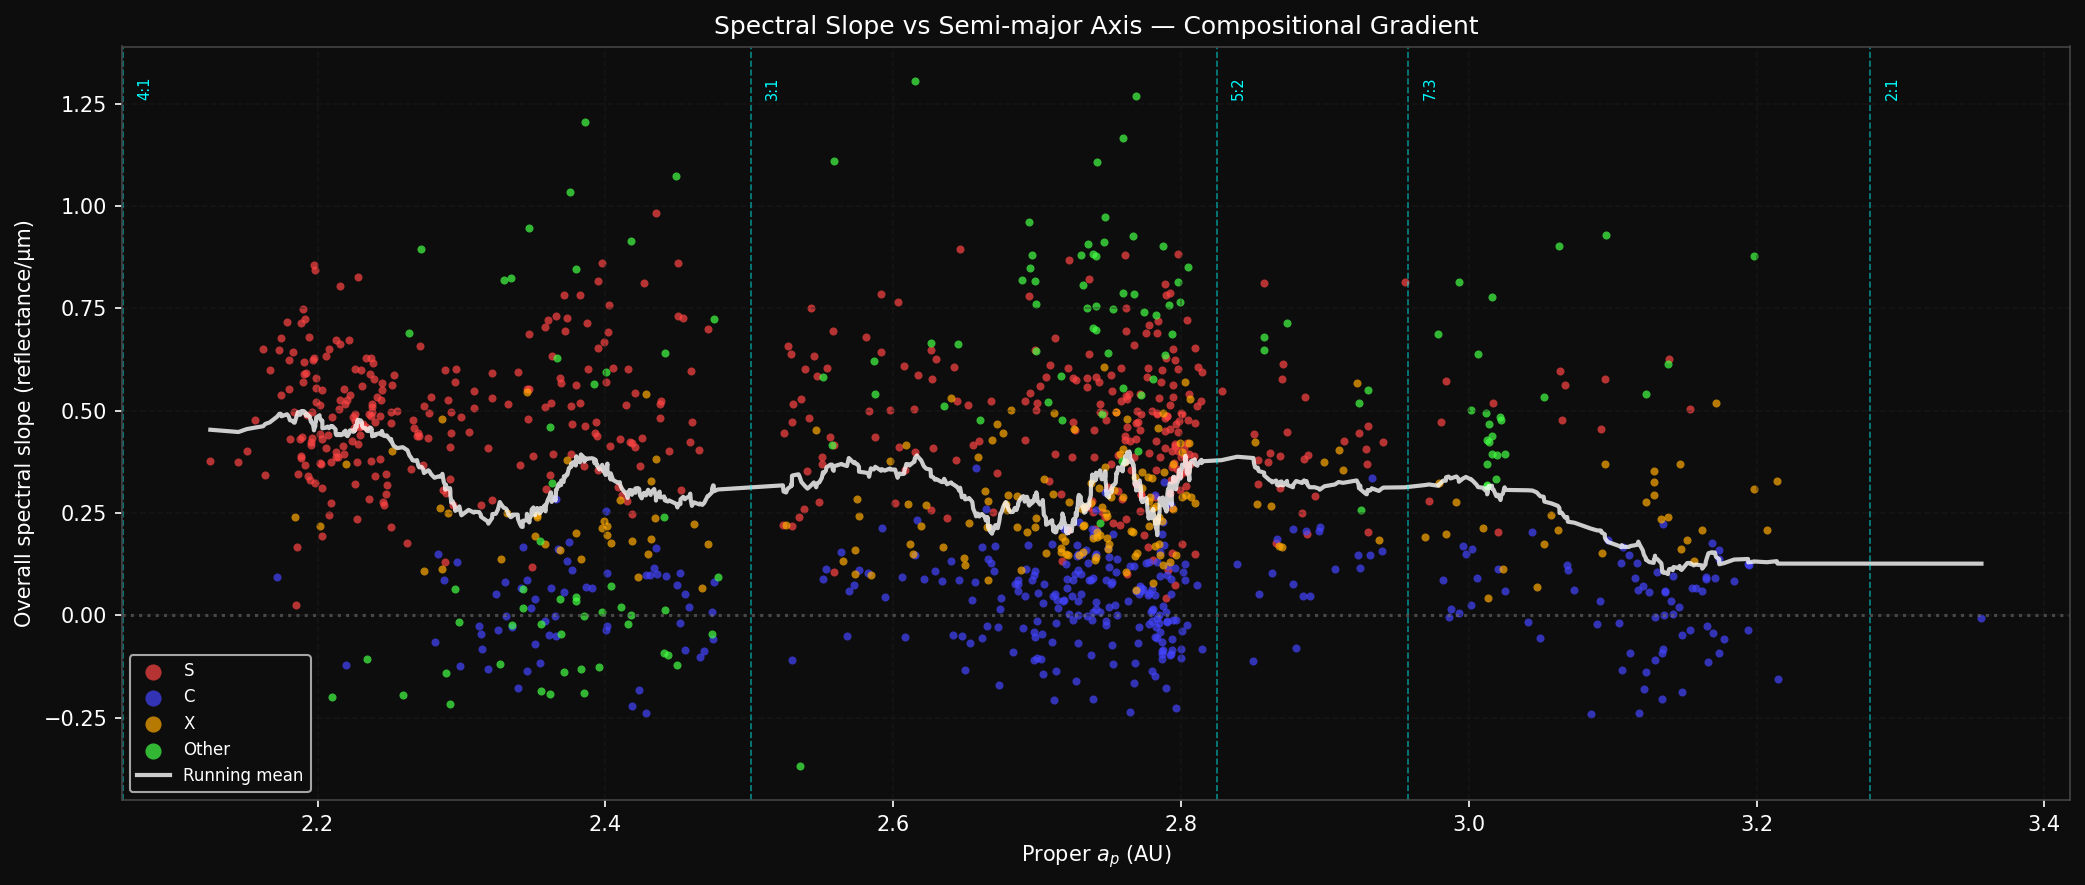

Correlation between a_p and spectral slope:
  Pearson  r = -0.1908,  p = 3.81e-11
  Spearman r = -0.1805, p = 4.15e-10


In [18]:
fig, ax = plt.subplots(figsize=(14, 6))

for group in groups:
    mask = unified_df['Main Group'] == group
    ax.scatter(
        unified_df.loc[mask, 'a_p'],
        unified_df.loc[mask, 'slope_overall'],
        s=15, c=TAX_COLORS[group], alpha=0.7,
        linewidths=0, label=f'{group}'
    )

# Running mean
from scipy.ndimage import uniform_filter1d
sorted_idx    = unified_df['a_p'].argsort()
a_sorted      = unified_df['a_p'].values[sorted_idx]
slope_sorted  = unified_df['slope_overall'].values[sorted_idx]
running_mean  = uniform_filter1d(slope_sorted, size=50)
ax.plot(a_sorted, running_mean, color='white',
        linewidth=2, alpha=0.8, label='Running mean')

for name, loc in RESONANCES.items():
    ax.axvline(loc, color='cyan', linewidth=0.8,
               linestyle='--', alpha=0.5)
    ax.text(loc + 0.01, 0.96, name,
            transform=ax.get_xaxis_transform(),
            color='cyan', fontsize=7, rotation=90, va='top')

ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Proper $a_p$ (AU)')
ax.set_ylabel('Overall spectral slope (reflectance/μm)')
ax.set_title('Spectral Slope vs Semi-major Axis — Compositional Gradient')
ax.legend(fontsize=8, markerscale=2)
ax.grid(True)

plt.tight_layout()
# plt.savefig(os.path.join(plots_path, '02_spectral_slope_gradient.png'),
#             dpi=200, bbox_inches='tight')
plt.show()

# Correlation between a_p and slope
from scipy.stats import pearsonr, spearmanr
r_pearson,  p_pearson  = pearsonr(unified_df['a_p'], unified_df['slope_overall'])
r_spearman, p_spearman = spearmanr(unified_df['a_p'], unified_df['slope_overall'])
print(f"Correlation between a_p and spectral slope:")
print(f"  Pearson  r = {r_pearson:.4f},  p = {p_pearson:.2e}")
print(f"  Spearman r = {r_spearman:.4f}, p = {p_spearman:.2e}")

In [19]:
print("=" * 60)
print("BELT COMPOSITION MAPPING — SUMMARY")
print("=" * 60)

print("\n--- Overall Class Distribution ---")
for group in groups:
    n   = (unified_df['Main Group'] == group).sum()
    pct = 100 * n / len(unified_df)
    print(f"  {group:<8}: {n:>4}  ({pct:.1f}%)")

print("\n--- Belt Zone Dominant Type ---")
for zone_name, (a_min, a_max) in zones.items():
    zone = unified_df[
        (unified_df['a_p'] >= a_min) &
        (unified_df['a_p'] <  a_max)
    ]
    dominant = zone['Main Group'].value_counts().index[0]
    dom_pct  = 100 * zone['Main Group'].value_counts().iloc[0] / len(zone)
    print(f"  {zone_name.replace(chr(10),' '):<25}: "
          f"{dominant} ({dom_pct:.1f}%)")

print("\n--- Spectral Slope by Class ---")
for group in groups:
    mask  = unified_df['Main Group'] == group
    slope = unified_df.loc[mask, 'slope_overall']
    print(f"  {group:<8}: mean={slope.mean():>7.4f}  "
          f"std={slope.std():.4f}")

BELT COMPOSITION MAPPING — SUMMARY

--- Overall Class Distribution ---
  S       :  488  (41.3%)
  C       :  357  (30.2%)
  X       :  196  (16.6%)
  Other   :  140  (11.9%)

--- Belt Zone Dominant Type ---
  Inner (2.0–2.5)          : S (60.7%)
  Middle (2.5–2.95)        : S (36.6%)
  Outer (2.95–3.5)         : C (52.2%)

--- Spectral Slope by Class ---
  S       : mean= 0.4772  std=0.1604
  C       : mean= 0.0386  std=0.1115
  X       : mean= 0.2618  std=0.1170
  Other   : mean= 0.4931  std=0.3867


In [ ]:
import pickle

belt_mapping_results = {
    'cs_gradient'   : cs_gradient,
    'zone_taxonomy' : zone_tax_df,
    'chi2'          : chi2,
    'p_value'       : p,
    'r_pearson'     : r_pearson,
    'r_spearman'    : r_spearman,
}

with open(os.path.join(results_path, '02_belt_mapping_results.pkl'), 'wb') as f:
    pickle.dump(belt_mapping_results, f)

Saved → data/results/02_belt_mapping_results.pkl
